In [34]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS

from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_groq import ChatGroq

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [35]:
docs = (
    PyPDFLoader("./documents/book1.pdf").load() +
    PyPDFLoader("./documents/book2.pdf").load() +
    PyPDFLoader("./documents/book3.pdf").load()
)

In [36]:

# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [37]:

len(chunks)

6393

In [38]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = FAISS.from_documents(chunks, embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2300.04it/s]


In [39]:

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [40]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [41]:
class State(TypedDict):
  question: str
  docs: List[Document]
  answer: str

In [42]:
def retrieve(state):
  q = state['question']
  return {'docs':retriever.invoke(q)}

In [43]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

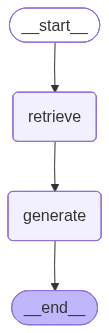

In [44]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [45]:
res = app.invoke({'question':'what is a transformer in deep learning','docs':[],'answer':''})
print(res['answer'])

which combines the fit() and transform() methods into one step. 
This is useful when you want to perform both operations in one go. 
However, it is generally recommended to use fit() and transform() 
separately for better control and understanding of the data. 

Note: The context provided does not mention deep learning.


In [46]:
res = app.invoke({'question':'Explain bias variance tradeoff','docs':[],'answer':''})
print(res['answer'])

The bias-variance tradeoff refers to the balance between two types of errors that can occur in a model: bias and variance. 

**Bias** is the error introduced by wrong assumptions about the data, such as assuming a linear relationship when the actual relationship is quadratic. A high-bias model is likely to underfit the training data, meaning it will not capture the underlying patterns in the data.

**Variance**, on the other hand, is the error introduced by a model's excessive sensitivity to small variations in the training data. A model with many degrees of freedom, such as a high-degree polynomial, can fit the training data very closely but will have high variance, meaning it will not generalize well to new, unseen data.

The goal is to find a model that balances these two types of errors, as a model with low bias and high variance will overfit the data, while a model with high bias and low variance will underfit the data. The optimal model is one that leads to the best balance betwe

In [47]:

print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

3.2. The Bias-Variance Decomposition 151
Figure 3.6 Plot of squared bias and variance,
together with their sum, correspond-
ing to the results shown in Fig-
ure 3.5. Also shown is the average
test set error for a test data set size
of 1000 points. The minimum value
of (bias)2 + variance occurs around
ln λ = −0.31, which is close to the
value that gives the minimum error
on the test data.
lnλ
−3 −2 −1 0 1 2
0
0.03
0.06
0.09
0.12
0.15
(bias)2
variance
(bias)2 + variance
test error
ﬁt a model with 24 Gaussian basis functions by minimizing the regularized error
function (3.27) to give a prediction function y(l)(x) as shown in Figure 3.5. The
top row corresponds to a large value of the regularization coefﬁcientλ that gives low
variance (because the red curves in the left plot look similar) but high bias (because
****************************************************************************************************
with respect to multiple data sets.
We can also examine the bias-variance trade-